In [1]:
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

## Utility Functions

In [2]:
def normalize_pixels(X):
    """
    Scale pixel values from [0, 255] to [0, 1].
    Normalization helps gradient-based models converge faster.
    For Random Forest it has minimal impact but is good practice
    for pipeline consistency if models are swapped later.
    """
    return X / 255.0


def encode_labels(y):
    """
    Convert string labels returned by fetch_openml to integers.
    fetch_openml returns labels as strings by default ('0'–'9').
    scikit-learn classifiers expect numeric labels.
    """
    return y.astype(int)


def split_data(X, y):
    """
    Split dataset into 80% train and 20% test with a fixed random seed.
    random_state=42 ensures reproducibility across runs.
    """
    return train_test_split(X, y, test_size=0.2, random_state=42)


def plot_confusion_matrix(cm, title, normalize=False):
    """
    Plot a confusion matrix heatmap.
    normalize=True divides each row by its sum so values fall in [0, 1].
    Normalized view is more informative when classes are imbalanced because
    raw counts for large classes visually dominate the colormap.
    """
    if normalize:
        # Row-wise normalization: each cell becomes the fraction of true-label
        # samples predicted as that class (i.e. per-class recall breakdown).
        cm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        fmt = ".2f"
        vmin, vmax = 0.0, 1.0
    else:
        fmt = "d"
        vmin, vmax = None, None

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        cmap="Blues",
        annot=True,
        fmt=fmt,
        vmin=vmin,
        vmax=vmax,
    )
    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

## 1. Load & Preprocess

In [3]:
# Load MNIST — 70,000 samples, 784 features (28x28 pixels), 10 classes
mnist = fetch_openml("mnist_784", version=1, as_frame=False)
X = mnist.data
y = mnist.target

# Preprocess
X = normalize_pixels(X)
y = encode_labels(y)

# Split
X_train, X_test, y_train, y_test = split_data(X, y)

## 2. Multi-Classifier Comparison

Before committing to Random Forest we benchmark four classifiers with their
default hyperparameters. The goal is an empirically informed model choice
rather than an arbitrary one.

- **Decision Tree** — simple baseline; high variance, prone to overfit on raw pixels.
- **Naive Bayes (Gaussian)** — fast but assumes feature independence, which
  rarely holds for adjacent pixels.
- **SVM (RBF kernel)** — strong on image tasks; expensive to train at 56k samples
  so we subsample for the comparison.
- **Random Forest** — ensemble of trees; trades some bias for large variance
  reduction, generally robust without heavy tuning.

In [4]:
# SVM training cost is O(n²–n³) in samples, making a full 56k-sample fit
# impractical here. We subsample 10k points so all four classifiers can be
# compared on equal footing within a reasonable time budget.
SUBSAMPLE = 10_000
rng = np.random.default_rng(42)
idx = rng.choice(len(X_train), size=SUBSAMPLE, replace=False)
X_sub, y_sub = X_train[idx], y_train[idx]

classifiers = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes":   GaussianNB(),
    # RBF kernel with C=5 is a reasonable starting point for MNIST;
    # probability=False speeds up prediction since we only need hard labels.
    "SVM (RBF)": SVC(kernel="rbf", C=5, gamma="scale", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
}

comparison_results = {}

for name, model in classifiers.items():
    model.fit(X_sub, y_sub)
    preds = model.predict(X_test)
    # Macro-F1 averages F1 across all classes with equal weight, making it
    # class-size-agnostic — the right metric for balanced datasets like MNIST
    # and a fair summary statistic for a 10-class problem.
    macro_f1 = f1_score(y_test, preds, average="macro")
    comparison_results[name] = macro_f1
    print(f"{name:<20} Macro-F1: {macro_f1:.4f}")

Decision Tree        Macro-F1: 0.8083
Naive Bayes          Macro-F1: 0.5280
SVM (RBF)            Macro-F1: 0.9668
Random Forest        Macro-F1: 0.9482


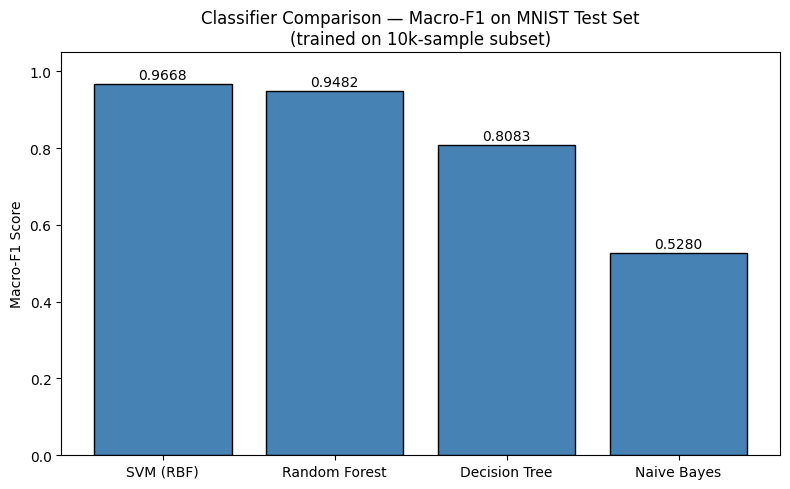

In [5]:
# Bar plot — sort descending so the best model is immediately visible at left.
names  = list(comparison_results.keys())
scores = list(comparison_results.values())
order  = np.argsort(scores)[::-1]

plt.figure(figsize=(8, 5))
bars = plt.bar(
    [names[i] for i in order],
    [scores[i] for i in order],
    color="steelblue",
    edgecolor="black",
)
# Annotate each bar with its exact score to avoid misreading axis ticks.
for bar, i in zip(bars, order):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{scores[i]:.4f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )
plt.ylim(0, 1.05)
plt.ylabel("Macro-F1 Score")
plt.title("Classifier Comparison — Macro-F1 on MNIST Test Set\n(trained on 10k-sample subset)")
plt.tight_layout()
plt.show()

## 3. Hyperparameter Tuning — Random Forest

Random Forest exposes several key hyperparameters:

| Hyperparameter | Effect |
|---|---|
| `n_estimators` | More trees → lower variance; diminishing returns after ~200 |
| `max_depth` | Limits tree depth; prevents overfit, trades some accuracy |
| `min_samples_split` | Min samples to split a node; higher = simpler trees |
| `max_features` | Features considered per split; `sqrt` is standard for classification |

We use **GridSearchCV** with 3-fold cross-validation on the subsample.
GridSearchCV exhaustively tries every combination in the parameter grid and
returns the one with the highest mean CV score.

In [6]:
param_grid = {
    "n_estimators":    [100, 200],
    # None lets trees grow fully; explicit depths guard against overfit.
    "max_depth":       [None, 20, 30],
    # min_samples_split=2 is the scikit-learn default; 5 adds light regularization.
    "min_samples_split": [2, 5],
    # sqrt(784) ≈ 28 features per split — the standard heuristic for classification.
    "max_features":    ["sqrt"],
}

# cv=3 keeps wall time manageable; scoring on macro-F1 matches our comparison metric.
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring="f1_macro",
    n_jobs=-1,   # use all available CPU cores
    verbose=1,
)
grid_search.fit(X_sub, y_sub)

print("Best parameters:",   grid_search.best_params_)
print("Best CV Macro-F1:",  f"{grid_search.best_score_:.4f}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
Best CV Macro-F1: 0.9457


## 4. Final Model — Tuned Random Forest on Full Training Set

In [7]:
# Re-train the best configuration on the *full* training split (56k samples)
# so the final model benefits from all available data.
best_params = grid_search.best_params_
clf = RandomForestClassifier(**best_params, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall    = recall_score(y_test, y_pred, average="macro")
macro_f1  = f1_score(y_test, y_pred, average="macro")

print(f"Accuracy:        {accuracy:.4f}")
print(f"Macro Precision: {precision:.4f}")
print(f"Macro Recall:    {recall:.4f}")
print(f"Macro F1:        {macro_f1:.4f}")

Accuracy:        0.9681
Macro Precision: 0.9679
Macro Recall:    0.9679
Macro F1:        0.9679


## 5. Class-wise Metrics — Classification Report

In [8]:
# classification_report prints per-class precision, recall, and F1 alongside
# support (number of true samples per class). This surfaces which digits are
# harder to classify — useful even when the dataset is roughly balanced.
print(classification_report(y_test, y_pred, target_names=[str(i) for i in range(10)]))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1343
           1       0.99      0.99      0.99      1600
           2       0.96      0.97      0.96      1380
           3       0.96      0.95      0.95      1433
           4       0.96      0.97      0.97      1295
           5       0.97      0.97      0.97      1273
           6       0.98      0.98      0.98      1396
           7       0.97      0.97      0.97      1503
           8       0.96      0.95      0.96      1357
           9       0.95      0.95      0.95      1420

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000



## 6. Confusion Matrices

We show both raw counts and a row-normalized version.
The normalized matrix is preferred when class sizes differ because each cell
represents the fraction of a true-class correctly (or incorrectly) predicted,
independent of how many total samples that class has.

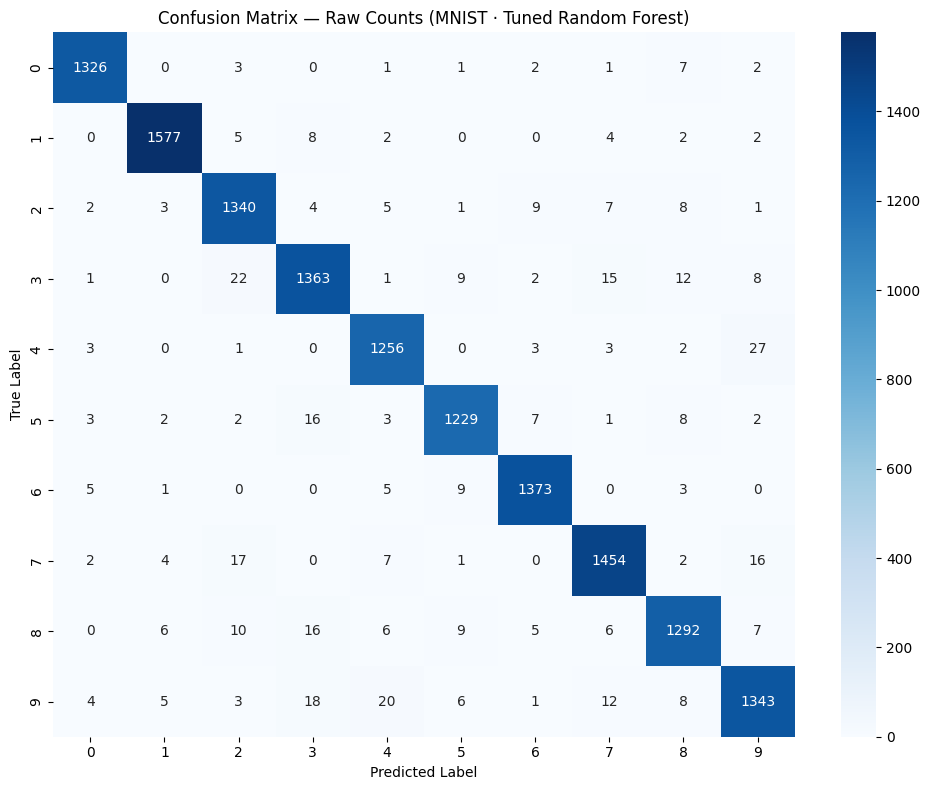

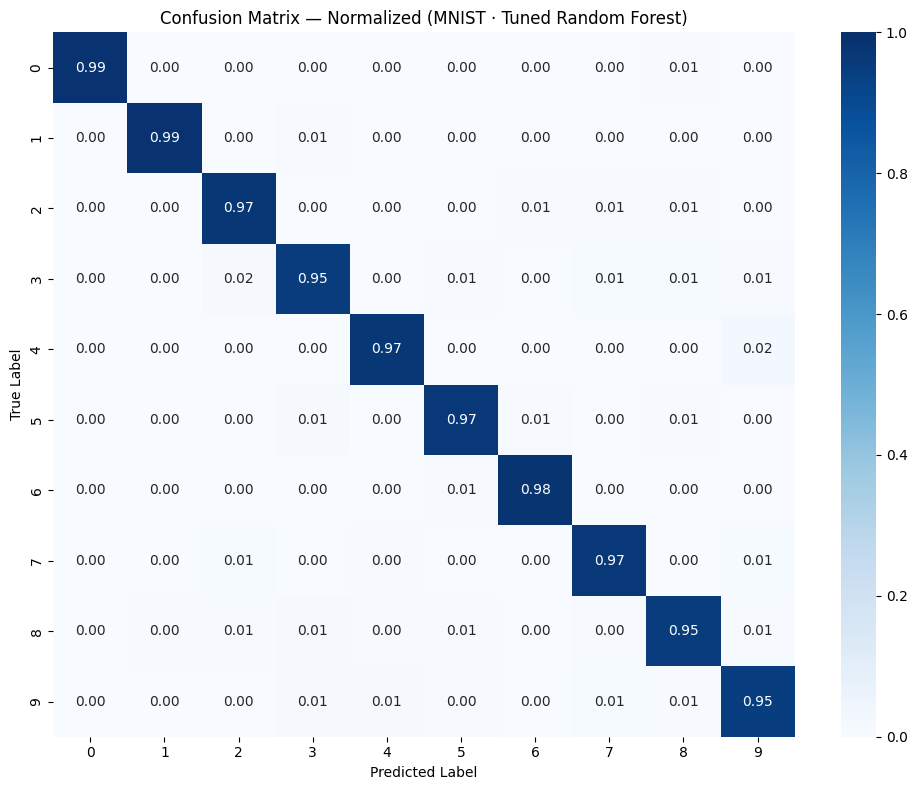

In [9]:
cm = confusion_matrix(y_test, y_pred)

# Raw count matrix — useful for spotting absolute error volumes.
plot_confusion_matrix(
    cm,
    title="Confusion Matrix — Raw Counts (MNIST · Tuned Random Forest)",
    normalize=False,
)

# Normalized matrix — each row sums to 1.0, making per-class error rates
# directly comparable regardless of class frequency.
plot_confusion_matrix(
    cm,
    title="Confusion Matrix — Normalized (MNIST · Tuned Random Forest)",
    normalize=True,
)